## Here all algorithms and methods are used to scan the documents perfectly or improve the quality of the photo or used in Camera to change brightness, or smth else

In [ ]:
# Here all algorithms and methods are used to scan the documents perfectly or improve the quality of the photo or used in Camera to change brightness, or smth else

In [14]:
# Our Setup, Import Libaries, Create our Imshow Function and Download our Images
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 5):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

baboon = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/Practice notebooks/baboon.jpg')
baboon_gray_scaled = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/Practice notebooks/baboon.jpg', 0)

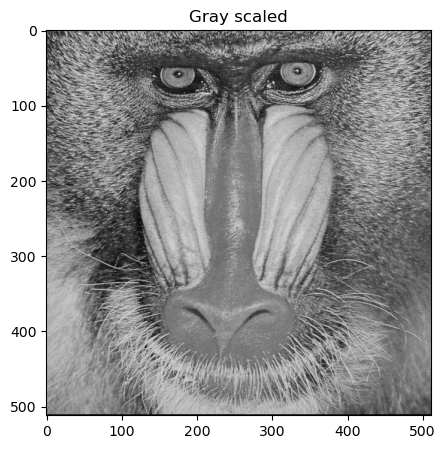

In [4]:
imshow('Gray scaled', baboon_gray_scaled)

### Threshold the image


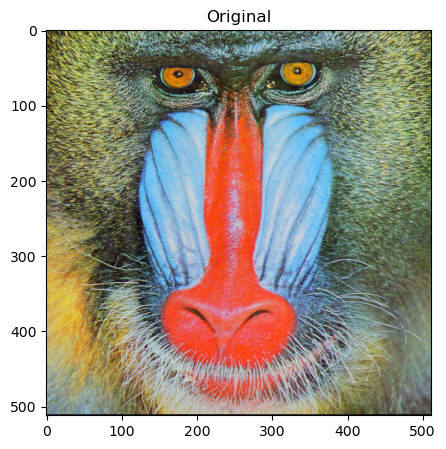

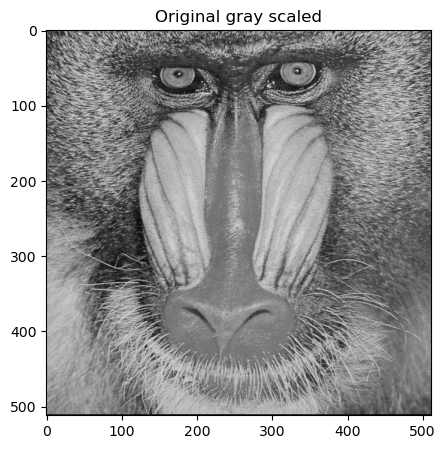

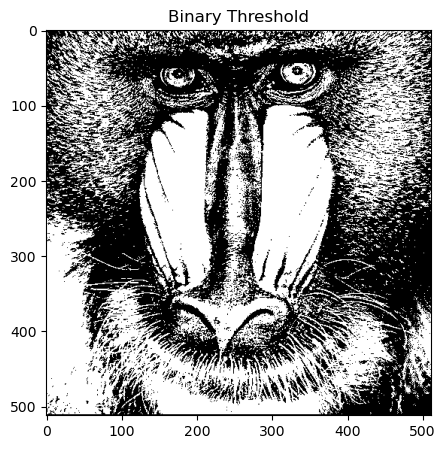

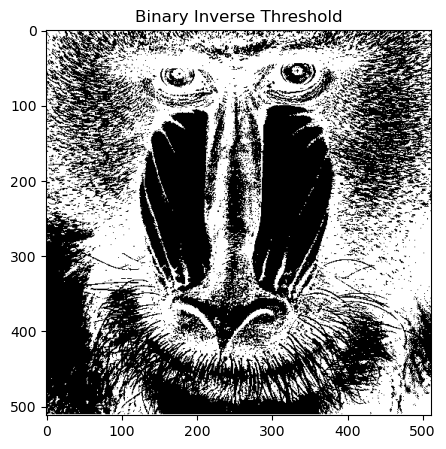

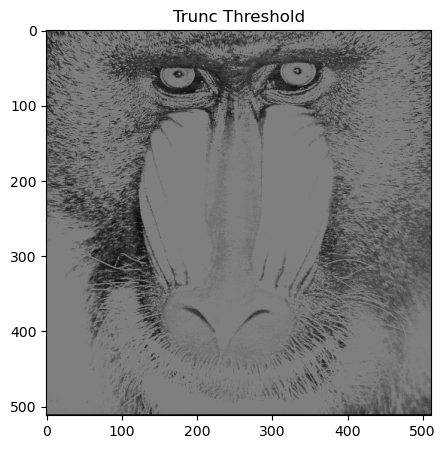

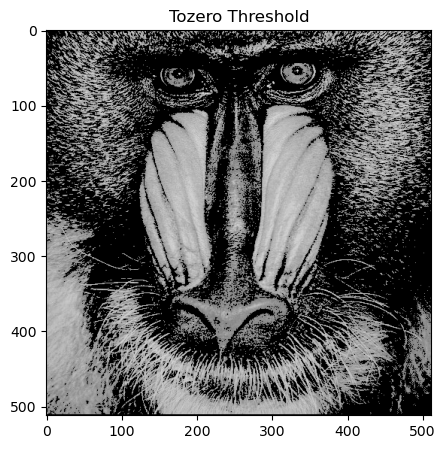

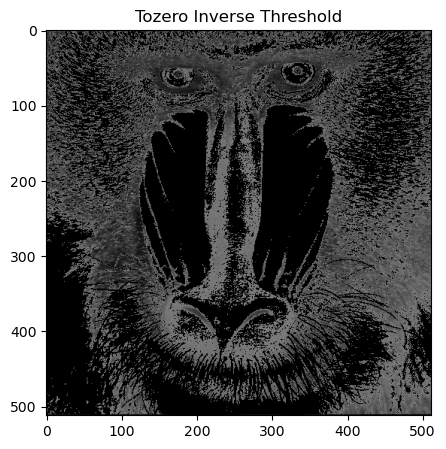

In [11]:
ret, thresh1 = cv2.threshold(baboon_gray_scaled, 127, 255, cv2.THRESH_BINARY)
ret, thresh2 = cv2.threshold(baboon_gray_scaled, 127, 255, cv2.THRESH_BINARY_INV)
ret, thresh3 = cv2.threshold(baboon_gray_scaled, 127, 255, cv2.THRESH_TRUNC)
ret, thresh4 = cv2.threshold(baboon_gray_scaled, 127, 255, cv2.THRESH_TOZERO)
ret, thresh5 = cv2.threshold(baboon_gray_scaled, 127, 255, cv2.THRESH_TOZERO_INV)


imshow('Original', baboon)
imshow('Original gray scaled', baboon_gray_scaled)
imshow('Binary Threshold', thresh1)
imshow('Binary Inverse Threshold', thresh2)
imshow('Trunc Threshold', thresh3)
imshow('Tozero Threshold', thresh4)
imshow('Tozero Inverse Threshold', thresh5)


### Adaptive Thresholding 


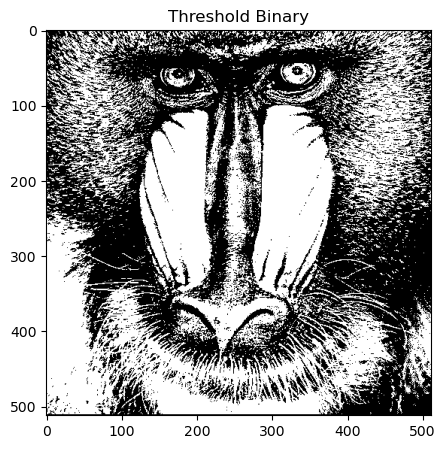

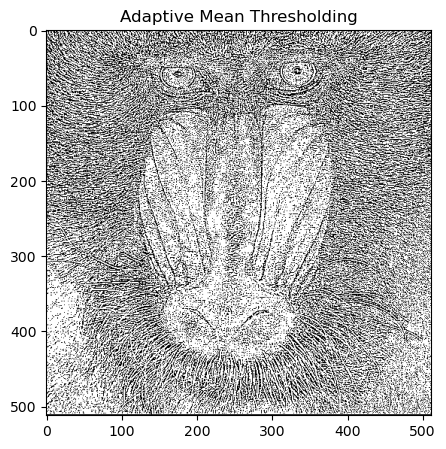

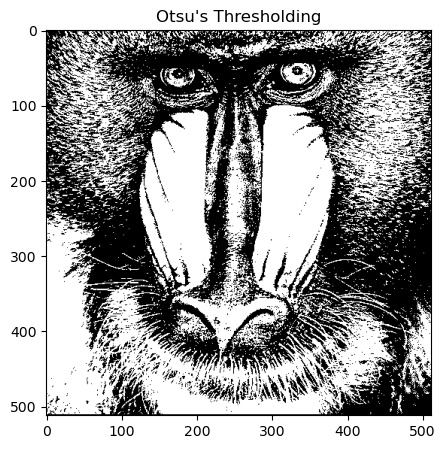

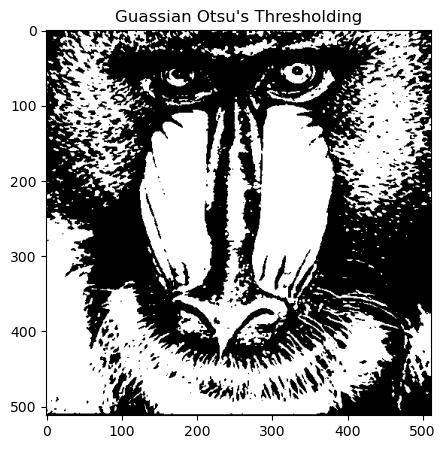

In [10]:
# Values below 127 goes to 0 (black, everything above goes to 255 (white)
ret,thresh1 = cv2.threshold(baboon_gray_scaled, 127, 255, cv2.THRESH_BINARY)
imshow('Threshold Binary', thresh1)

# It's good practice to blur images as it removes noise
#image = cv2.GaussianBlur(image, (3, 3), 0)

# Using adaptiveThreshold
thresh = cv2.adaptiveThreshold(baboon_gray_scaled, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 3, 5) 
imshow("Adaptive Mean Thresholding", thresh) 

_, th2 = cv2.threshold(baboon_gray_scaled, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow("Otsu's Thresholding", th2) 

# Otsu's thresholding after Gaussian filtering
blur = cv2.GaussianBlur(baboon_gray_scaled, (5,5), 0)
_, th3 = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow("Guassian Otsu's Thresholding", th3) 

### **SKImage Threshold Local**

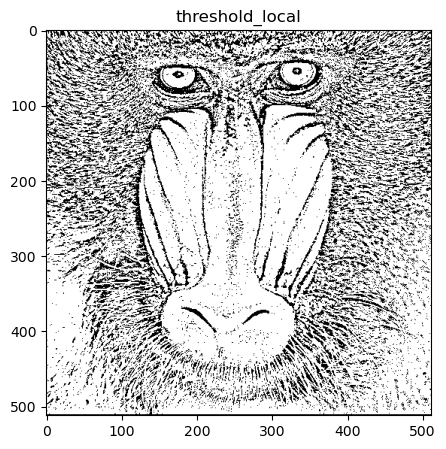

In [13]:
from skimage.filters import threshold_local

# We get the Value component from the HSV color space 
# then we apply adaptive thresholdingto 
V = cv2.split(cv2.cvtColor(baboon, cv2.COLOR_BGR2HSV))[2]
T = threshold_local(V, 25, offset=15, method="gaussian")

# Apply the threshold operation 
thresh = (V > T).astype("uint8") * 255
imshow("threshold_local", thresh)